# Timestep-Aligned Inversion Localization vs. Forward FYS

This notebook compares inversion-derived target-prompt masks with the forward FYS-TDM mask under a fixed, timestep-aligned protocol. It compares localization masks only; it does not rerun generation.

## 1. Frozen comparison protocol

Denoising steps `[2..8]` map to inversion steps `[12..6]`, which are aggregated as `[6..12]`. The aggregation follows FYS: per-step normalization, spatial softmax over the selected steps with scale `5.0`, weighted sum, Gaussian smoothing (`sigma=0.7`), and Otsu binarization.

In [1]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not find repository root")
    REPO_ROOT = REPO_ROOT.parent

MANIFEST_PATH = REPO_ROOT / "core/data/partedit_subset/pilot_12_manifest.json"
PROBE_ROOT = REPO_ROOT / "core/results/same_state_inversion_probe"
manifest = json.loads(MANIFEST_PATH.read_text())

NUM_STEPS = 15
FRONT = 2
INJECT = 4
TAIL_PAD = 1
SMOOTHING_SIGMA = 0.7
SOFTMAX_SCALE = 5.0
DENOISE_RECORD_END = NUM_STEPS - INJECT - 2 - TAIL_PAD
denoise_steps = list(range(FRONT, DENOISE_RECORD_END + 1))
inversion_steps = [NUM_STEPS - 1 - step for step in denoise_steps]
selected_inversion_steps = sorted(inversion_steps)

print("cases:", len(manifest))
print("denoise control steps:", denoise_steps)
print("timestep-aligned inversion steps:", selected_inversion_steps)

cases: 12
denoise control steps: [2, 3, 4, 5, 6, 7, 8]
timestep-aligned inversion steps: [6, 7, 8, 9, 10, 11, 12]


## 2. Signals and fair aggregation

The three inversion signals are:

- `part attention`;
- `part+edit attention`;
- strict `gate attention = part attention × delta-v`.

The forward reference uses the soft FYS mask for AP and its saved binary mask for IoU and area metrics. Both are read from the original FYS denoising run; GT masks are used only for metrics.

In [2]:
def load_map(path):
    value = np.asarray(np.load(path), dtype=np.float32).squeeze()
    if value.ndim != 2 or not np.isfinite(value).all():
        raise ValueError(f"Invalid map: {path} -> {value.shape}")
    return value

def normalize01(value):
    value = np.asarray(value, dtype=np.float32)
    lo, hi = float(value.min()), float(value.max())
    return (value - lo) / (hi - lo) if hi > lo else np.zeros_like(value)

def otsu_threshold(value):
    value = np.asarray(value, dtype=np.float32)
    hist, edges = np.histogram(value.ravel(), bins=256)
    centers = (edges[:-1] + edges[1:]) / 2
    wb = np.cumsum(hist); wf = hist.sum() - wb
    valid = (wb > 0) & (wf > 0)
    mb = np.cumsum(hist * centers) / np.maximum(wb, 1e-12)
    mf = (np.cumsum((hist * centers)[::-1]) / np.maximum(np.cumsum(hist[::-1]), 1e-12))[::-1]
    between = wb * wf * (mb - mf) ** 2
    between[~valid] = -1
    return float(centers[np.argmax(between)])

def resize_gt(path, shape):
    return np.asarray(Image.open(path).convert("L").resize((shape[1], shape[0]), Image.Resampling.NEAREST)) > 0

def fys_aggregate(step_maps, scale=SOFTMAX_SCALE):
    """Match FYS temporal aggregation: per-step normalization, spatial softmax over steps, weighted sum."""
    normalized = np.stack([normalize01(x) for x in step_maps], axis=0)
    weights = np.exp(scale * normalized - np.max(scale * normalized, axis=0, keepdims=True))
    weights /= np.maximum(weights.sum(axis=0, keepdims=True), 1e-12)
    soft = (normalized * weights).sum(axis=0)
    smoothed = gaussian_filter(soft, sigma=SMOOTHING_SIGMA)
    binary = smoothed > otsu_threshold(smoothed)
    return soft.astype(np.float32), smoothed.astype(np.float32), binary.astype(np.uint8)

def average_precision(score, gt):
    order = np.argsort(-score.ravel(), kind="stable")
    labels = gt.ravel()[order]
    tp = np.cumsum(labels)
    precision = tp / (np.arange(labels.size) + 1)
    return float((precision * labels).sum() / max(int(gt.sum()), 1))

def metric_row(case_uid, part_size, part, edit, method, score, binary, gt):
    score = normalize01(score); binary = np.asarray(binary).astype(bool); gt = np.asarray(gt).astype(bool)
    union = np.logical_or(binary, gt).sum()
    return {"case_uid":case_uid,"part_size":part_size,"part":part,"edit":edit,"method":method,
            "gt_area":float(gt.mean()),"pred_area":float(binary.mean()),
            "area_ratio":float(binary.mean()/gt.mean()),
            "iou":float(np.logical_and(binary,gt).sum()/union) if union else np.nan,
            "soft_ap":average_precision(score,gt),
            "inside_mass":float(score[gt].sum()/max(score.sum(),1e-12)),
            "outside_mass":float(score[~gt].sum()/max(score.sum(),1e-12))}

## 3. Build timestep-aligned masks and metrics

In [3]:
def probe_dir(uid):
    path=PROBE_ROOT/uid/"seed_000"
    if not (path/"probe_metadata.json").exists(): raise FileNotFoundError(path)
    return path

rows=[]; cache={}
for record in manifest:
    uid=record["case_uid"]; rd=probe_dir(uid)
    steps=[int(x) for x in json.loads((rd/"probe_metadata.json").read_text())["recorded_step_indices"]]
    selected=[s for s in selected_inversion_steps if s in steps]
    if not selected: raise ValueError(f"No aligned steps for {uid}")
    v=[]; p=[]; pe=[]; g=[]
    for step in selected:
        vv=normalize01(load_map(rd/"steps"/f"step_{step:02d}_velocity_delta.npy"))
        pp=normalize01(load_map(rd/"steps"/f"step_{step:02d}_part_attention.npy"))
        ee=normalize01(load_map(rd/"steps"/f"step_{step:02d}_edit_attention.npy"))
        v.append(vv); p.append(pp); pe.append(normalize01(pp+ee)); g.append(normalize01(pp*vv))
    shape=p[0].shape; gt=resize_gt(REPO_ROOT/record["gt_mask"],shape)
    inversion={}
    for name,maps in [("inversion_part_attention",p),("inversion_part_edit_attention",pe),("inversion_gate_attention",g)]:
        soft,smooth,binary=fys_aggregate(maps)
        inversion[name]=(soft,smooth,binary)
        rows.append(metric_row(uid,record["part_size"],record["part"],record["edit"],name,smooth,binary,gt))
    forward_dir=REPO_ROOT/"core/results/follow_your_shape"/uid/"seed_000"/"tdm"
    forward_path=forward_dir/"binary_tdm_mask.npy"
    forward_soft_path=forward_dir/"smoothed_soft_tdm.npy"
    if not forward_path.exists() or not forward_soft_path.exists(): raise FileNotFoundError(forward_path if not forward_path.exists() else forward_soft_path)
    forward=load_map(forward_path).astype(np.uint8)
    forward_score=load_map(forward_soft_path)
    forward_gt=resize_gt(REPO_ROOT/record["gt_mask"],forward.shape)
    rows.append(metric_row(uid,record["part_size"],record["part"],record["edit"],"forward_fys_tdm",forward_score,forward,forward_gt))
    cache[uid]={"record":record,"gt":gt,"inversion":inversion,"forward":forward}

metrics_df=pd.DataFrame(rows)
OUT_ROOT=REPO_ROOT/"core/results/inversion_vs_forward_eval"; OUT_ROOT.mkdir(parents=True,exist_ok=True)
metrics_df.to_csv(OUT_ROOT/"per_case_metrics.csv",index=False)
summary=metrics_df.groupby("method",as_index=False).agg(cases=("case_uid","nunique"),mean_iou=("iou","mean"),mean_soft_ap=("soft_ap","mean"),mean_area_ratio=("area_ratio","mean"),mean_inside_mass=("inside_mass","mean"),mean_outside_mass=("outside_mass","mean"))
summary.to_csv(OUT_ROOT/"summary.csv",index=False)
display(summary.round(4))


,method,cases,mean_iou,mean_soft_ap,mean_area_ratio,mean_inside_mass,mean_outside_mass
0,forward_fys_tdm,12,0.1735,0.2470,8.0423,0.1359,0.8641
1,inversion_gate_attention,12,0.4519,0.7065,2.1157,0.3868,0.6132
2,inversion_part_attention,12,0.4029,0.7301,3.8248,0.2779,0.7221
3,inversion_part_edit_attention,12,0.3585,0.7368,4.3014,0.2277,0.7723


## 4. Direct visual comparison

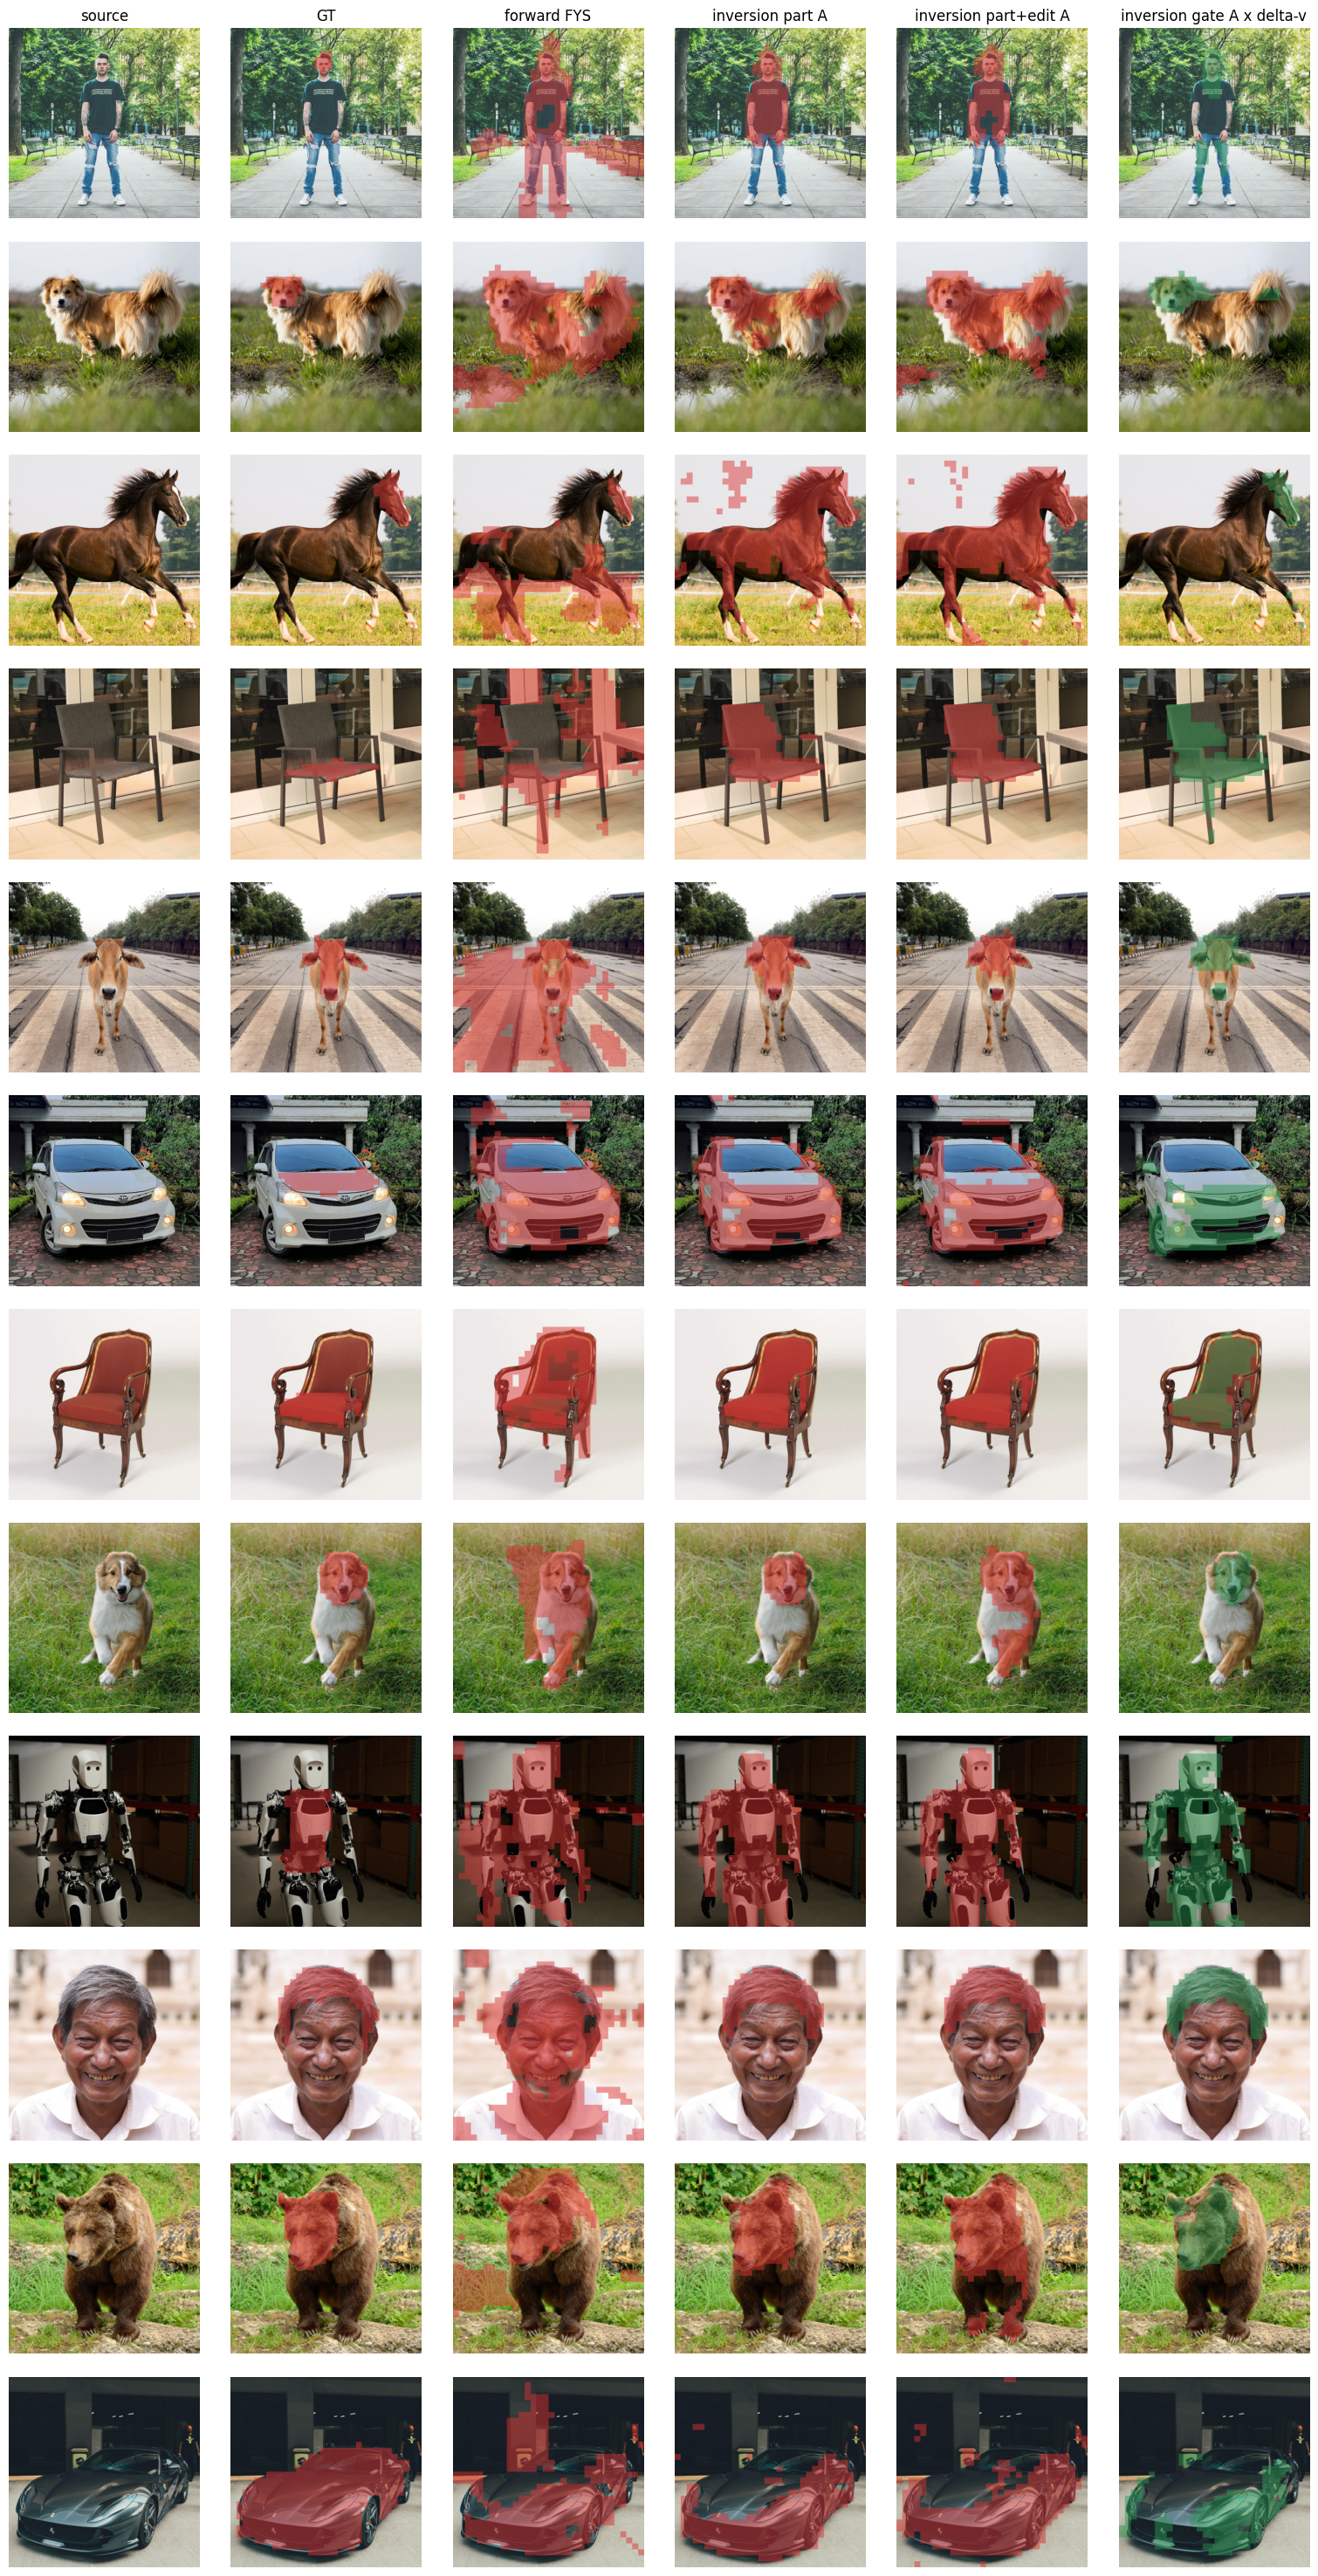

saved: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/inversion_vs_forward_eval/forward_vs_inversion_masks_seed0.png


In [4]:
def overlay(source_path,mask,color,alpha=.48):
    base=np.asarray(Image.open(source_path).convert("RGB").resize((384,384)))/255.
    m=np.asarray(Image.fromarray((np.asarray(mask,dtype=np.uint8)*255)).resize((384,384),Image.Resampling.NEAREST))>0
    tint=np.empty_like(base); tint[:]=np.asarray(color)/255.
    return np.where(m[...,None],base*(1-alpha)+tint*alpha,base)

fig,axes=plt.subplots(len(manifest),6,figsize=(18,2.5*len(manifest)),squeeze=False)
labels=["source","GT","forward FYS","inversion part A","inversion part+edit A","inversion gate A x delta-v"]
for j,label in enumerate(labels): axes[0,j].set_title(label)
for i,record in enumerate(manifest):
    item=cache[record["case_uid"]]; source=REPO_ROOT/record["source_image"]
    axes[i,0].imshow(Image.open(source).convert("RGB")); axes[i,0].axis("off")
    axes[i,0].set_ylabel(f'{record["case_uid"]}\n{record["part"]} -> {record["edit"]}',rotation=0,ha="right",va="center",fontsize=8,labelpad=34)
    axes[i,1].imshow(overlay(source,item["gt"],(220,50,50))); axes[i,1].axis("off")
    axes[i,2].imshow(overlay(source,item["forward"],(220,50,50))); axes[i,2].axis("off")
    for j,key,color in [(3,"inversion_part_attention",(220,50,50)),(4,"inversion_part_edit_attention",(220,50,50)),(5,"inversion_gate_attention",(40,150,80))]:
        axes[i,j].imshow(overlay(source,item["inversion"][key][2],color)); axes[i,j].axis("off")
fig.subplots_adjust(left=.15,right=.995,top=.98,bottom=.01,wspace=.02,hspace=.12)
fig_path=OUT_ROOT/"forward_vs_inversion_masks_seed0.png"; fig.savefig(fig_path,dpi=160,bbox_inches="tight",facecolor="white"); plt.show(); print("saved:",fig_path)

## 5. Parameter comparison

The two sources use the same source image, target prompt, model family, number of steps, smoothing, and thresholding. The only intentional difference is where the signal is measured: evolving forward denoise states for FYS versus source inversion states for the inversion probe.

In [5]:
parameter_table = pd.DataFrame([
    {"source": "forward FYS-TDM", "trajectory_state": "target denoising state", "step_selection": str(denoise_steps), "aligned_inversion_steps": "not applicable", "signal": "source-vs-target velocity difference", "aggregation": "temporal softmax, scale=5", "smoothing_sigma": SMOOTHING_SIGMA, "threshold": "Otsu"},
    {"source": "inversion part attention", "trajectory_state": "source inversion state", "step_selection": "mapped from FYS interval", "aligned_inversion_steps": str(selected_inversion_steps), "signal": "image-query mass to part token(s)", "aggregation": "temporal softmax, scale=5", "smoothing_sigma": SMOOTHING_SIGMA, "threshold": "Otsu"},
    {"source": "inversion part+edit attention", "trajectory_state": "source inversion state", "step_selection": "mapped from FYS interval", "aligned_inversion_steps": str(selected_inversion_steps), "signal": "image-query mass to part and edit tokens", "aggregation": "temporal softmax, scale=5", "smoothing_sigma": SMOOTHING_SIGMA, "threshold": "Otsu"},
    {"source": "inversion gate attention", "trajectory_state": "source inversion state", "step_selection": "mapped from FYS interval", "aligned_inversion_steps": str(selected_inversion_steps), "signal": "part attention x delta-v", "aggregation": "temporal softmax, scale=5", "smoothing_sigma": SMOOTHING_SIGMA, "threshold": "Otsu"},
])
parameter_table.to_csv(OUT_ROOT / "parameter_comparison.csv", index=False)
display(parameter_table)

,source,trajectory_state,step_selection,aligned_inversion_steps,signal,aggregation,smoothing_sigma,threshold
0,forward FYS-TDM,target denoising state,"[2, 3, 4, 5, 6, 7, 8]",not applicable,source-vs-target velocity difference,"temporal softmax, scale=5",0.7,Otsu
1,inversion part attention,source inversion state,mapped from FYS interval,"[6, 7, 8, 9, 10, 11, 12]",image-query mass to part token(s),"temporal softmax, scale=5",0.7,Otsu
2,inversion part+edit attention,source inversion state,mapped from FYS interval,"[6, 7, 8, 9, 10, 11, 12]",image-query mass to part and edit tokens,"temporal softmax, scale=5",0.7,Otsu
3,inversion gate attention,source inversion state,mapped from FYS interval,"[6, 7, 8, 9, 10, 11, 12]",part attention x delta-v,"temporal softmax, scale=5",0.7,Otsu


## 5. Arithmetic-mean aggregation

As a sensitivity check, the same timestep-aligned inversion signals are aggregated by an arithmetic mean instead of temporal softmax. Per-step normalization, Gaussian smoothing, Otsu thresholding, and metric definitions remain unchanged. This isolates whether temporal softmax is amplifying isolated high responses.

In [6]:
def mean_aggregate(step_maps):
    normalized = np.stack([normalize01(x) for x in step_maps], axis=0)
    soft = normalized.mean(axis=0)
    smoothed = gaussian_filter(soft, sigma=SMOOTHING_SIGMA)
    binary = smoothed > otsu_threshold(smoothed)
    return soft.astype(np.float32), smoothed.astype(np.float32), binary.astype(np.uint8)

mean_rows=[]
mean_cache={}
for record in manifest:
    uid=record["case_uid"]; rd=probe_dir(uid)
    steps=[int(x) for x in json.loads((rd/"probe_metadata.json").read_text())["recorded_step_indices"]]
    selected=[s for s in selected_inversion_steps if s in steps]
    signals={"mean_inversion_part_attention":[], "mean_inversion_part_edit_attention":[], "mean_inversion_gate_attention":[]}
    for step in selected:
        vv=normalize01(load_map(rd/"steps"/f"step_{step:02d}_velocity_delta.npy"))
        pp=normalize01(load_map(rd/"steps"/f"step_{step:02d}_part_attention.npy"))
        ee=normalize01(load_map(rd/"steps"/f"step_{step:02d}_edit_attention.npy"))
        signals["mean_inversion_part_attention"].append(pp)
        signals["mean_inversion_part_edit_attention"].append(normalize01(pp+ee))
        signals["mean_inversion_gate_attention"].append(normalize01(pp*vv))
    gt=resize_gt(REPO_ROOT/record["gt_mask"], signals["mean_inversion_part_attention"][0].shape)
    mean_cache[uid]={"record":record,"gt":gt,"masks":{}}
    for method,maps in signals.items():
        soft,smooth,binary=mean_aggregate(maps)
        mean_cache[uid]["masks"][method]=(soft,smooth,binary)
        mean_rows.append(metric_row(uid,record["part_size"],record["part"],record["edit"],method,smooth,binary,gt))

mean_metrics=pd.DataFrame(mean_rows)
mean_metrics.to_csv(OUT_ROOT/"mean_aggregation_metrics.csv",index=False)
mean_summary=mean_metrics.groupby("method",as_index=False).agg(cases=("case_uid","nunique"),mean_iou=("iou","mean"),mean_soft_ap=("soft_ap","mean"),mean_area_ratio=("area_ratio","mean"),mean_inside_mass=("inside_mass","mean"),mean_outside_mass=("outside_mass","mean"))
mean_summary.to_csv(OUT_ROOT/"mean_aggregation_summary.csv",index=False)
display(mean_summary.round(4))


,method,cases,mean_iou,mean_soft_ap,mean_area_ratio,mean_inside_mass,mean_outside_mass
0,mean_inversion_gate_attention,12,0.5011,0.7398,1.9497,0.3748,0.6252
1,mean_inversion_part_attention,12,0.3983,0.7250,3.9744,0.2649,0.7351
2,mean_inversion_part_edit_attention,12,0.3777,0.7431,4.3544,0.2277,0.7723


In [7]:
# Compare mean aggregation against temporal-softmax aggregation for inversion masks.
comparison_rows=[]
for uid in mean_cache:
    for mean_method,(soft,smooth,binary) in mean_cache[uid]["masks"].items():
        softmax_method=mean_method.replace("mean_", "")
        base_method=mean_method.replace("mean_", "")
        base_row=metrics_df[(metrics_df["case_uid"]==uid) & (metrics_df["method"]==base_method)].iloc[0].to_dict()
        mean_row=mean_metrics[(mean_metrics["case_uid"]==uid) & (mean_metrics["method"]==mean_method)].iloc[0].to_dict()
        comparison_rows.append({"case_uid":uid,"signal":base_method,"temporal_softmax_iou":base_row["iou"],"mean_iou":mean_row["iou"],"temporal_softmax_ap":base_row["soft_ap"],"mean_ap":mean_row["soft_ap"],"temporal_softmax_area_ratio":base_row["area_ratio"],"mean_area_ratio":mean_row["area_ratio"]})
comparison_df=pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUT_ROOT/"softmax_vs_mean_per_case.csv",index=False)
display(comparison_df.groupby("signal",as_index=False).agg(
    mean_softmax_iou=("temporal_softmax_iou","mean"), mean_iou=("mean_iou","mean"),
    mean_softmax_ap=("temporal_softmax_ap","mean"), mean_ap=("mean_ap","mean"),
    mean_softmax_area_ratio=("temporal_softmax_area_ratio","mean"), mean_area_ratio=("mean_area_ratio","mean"),
).round(4))


,signal,mean_softmax_iou,mean_iou,mean_softmax_ap,mean_ap,mean_softmax_area_ratio,mean_area_ratio
0,inversion_gate_attention,0.4519,0.5011,0.7065,0.7398,2.1157,1.9497
1,inversion_part_attention,0.4029,0.3983,0.7301,0.7250,3.8248,3.9744
2,inversion_part_edit_attention,0.3585,0.3777,0.7368,0.7431,4.3014,4.3544


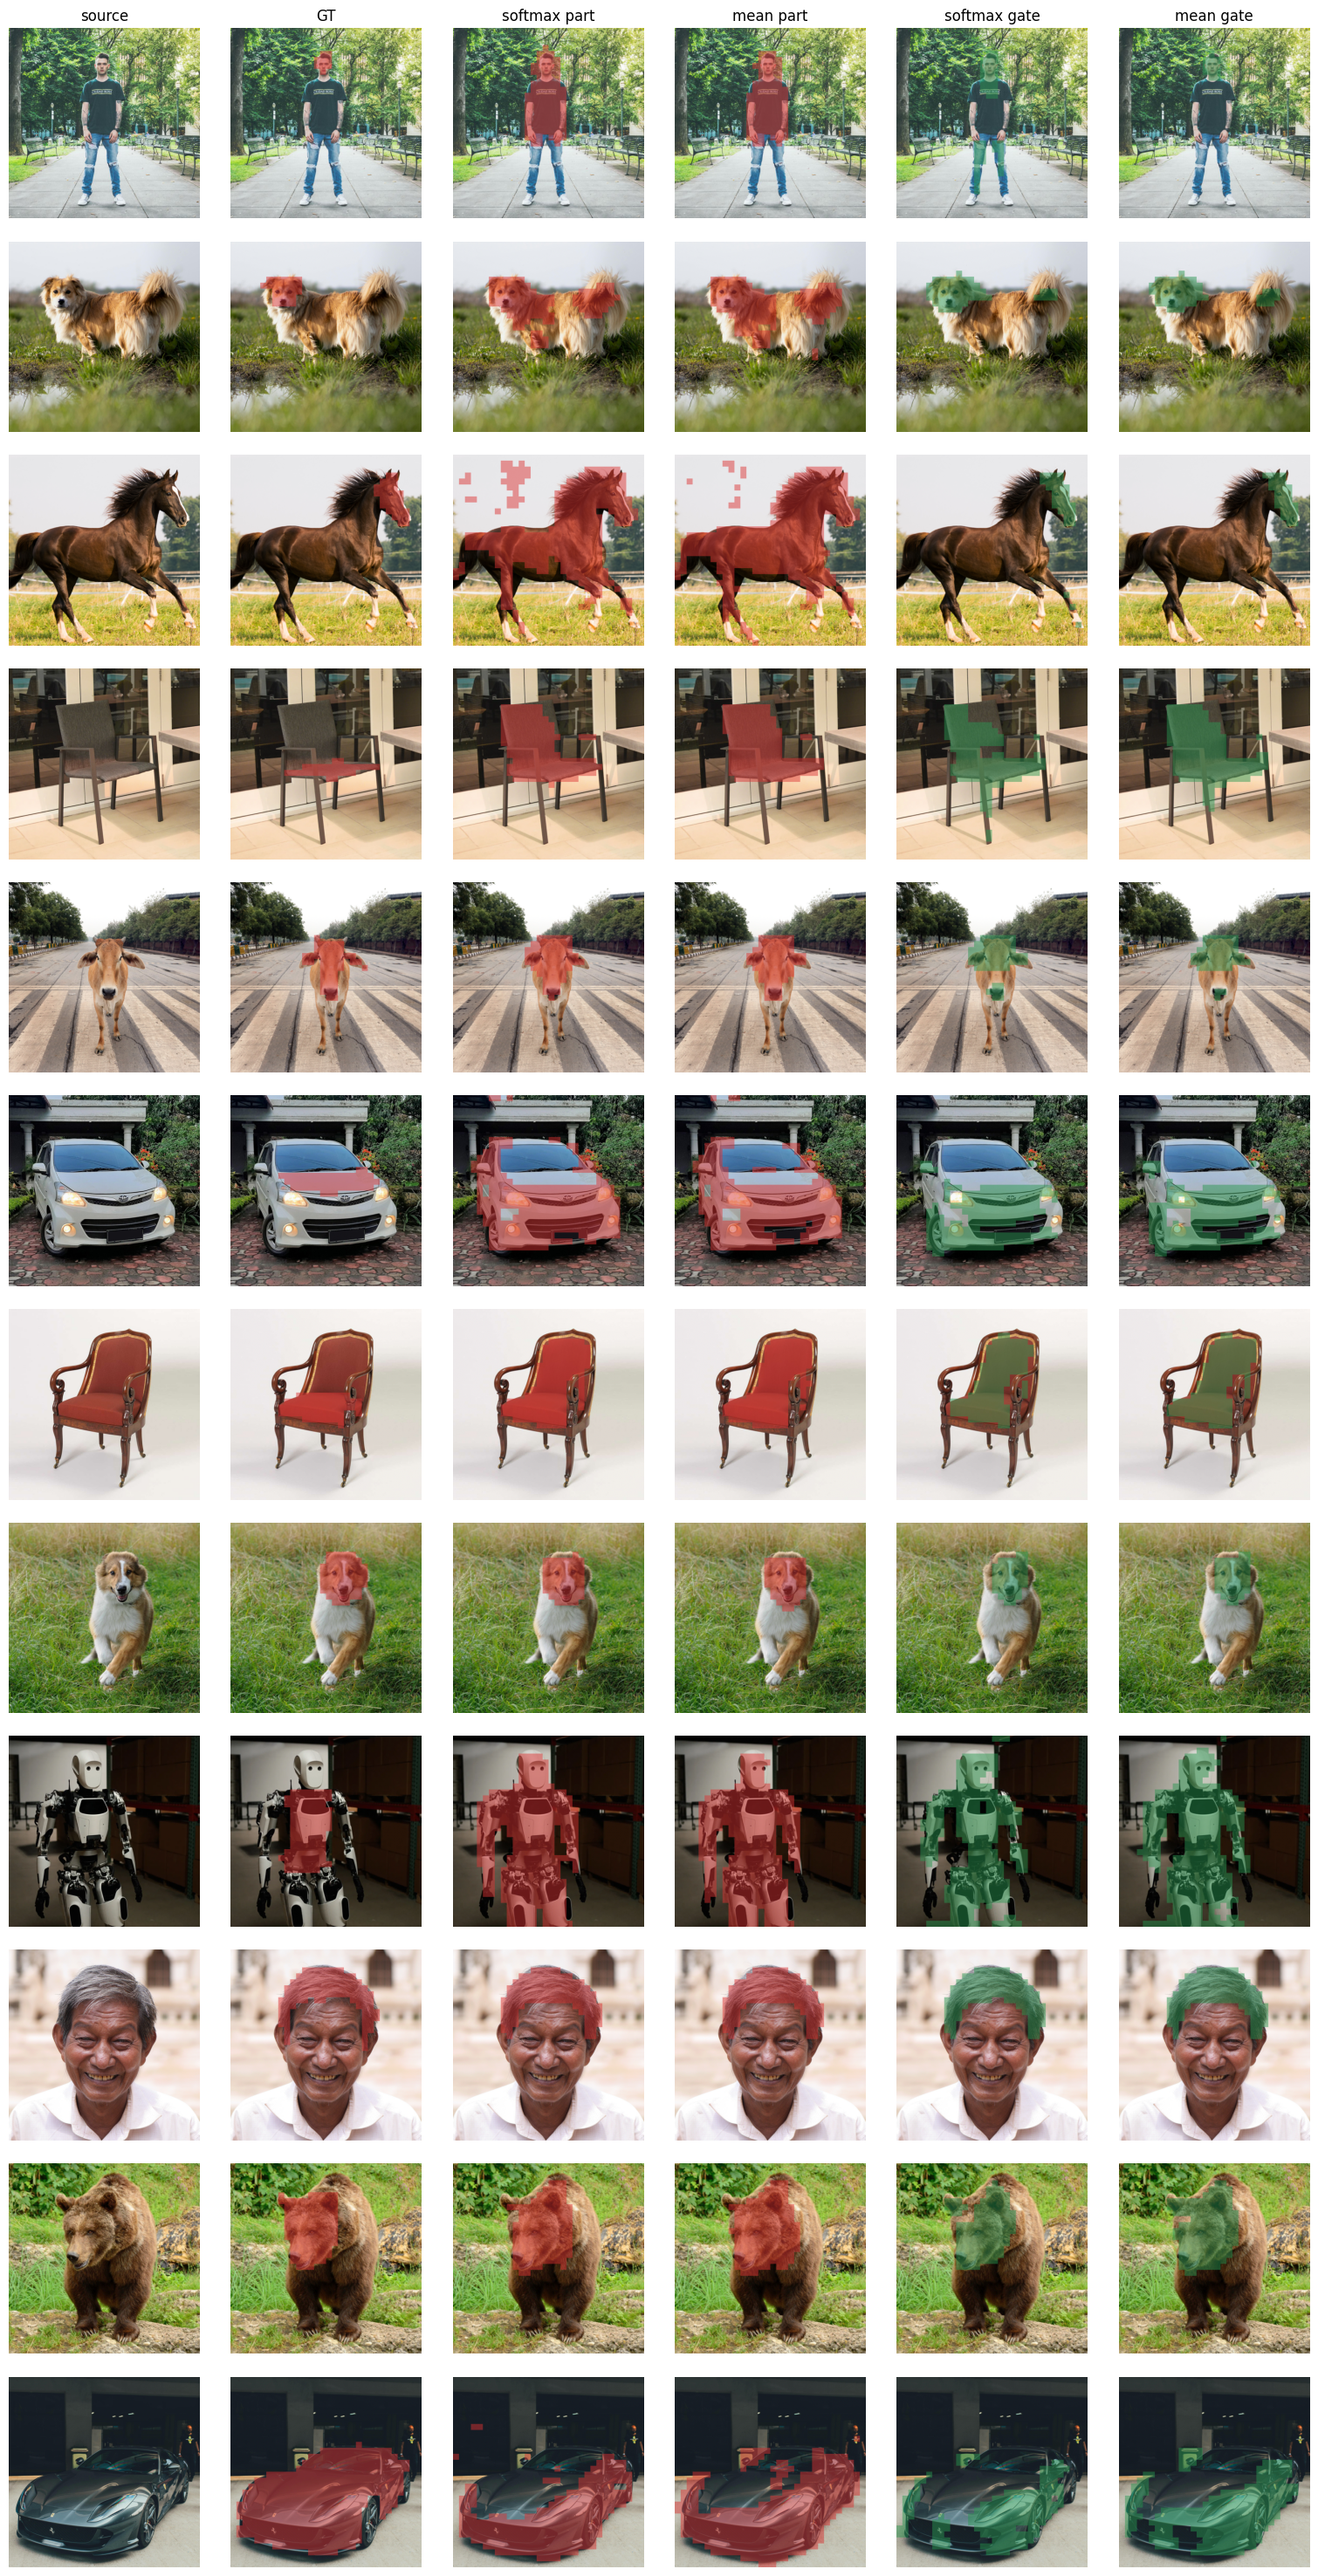

saved: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/inversion_vs_forward_eval/softmax_vs_mean_masks_seed0.png


In [8]:
# Visual comparison for the same seed-0 cases used above.
mean_labels=["source","GT","softmax part","mean part","softmax gate","mean gate"]
fig,axes=plt.subplots(len(manifest),6,figsize=(18,2.5*len(manifest)),squeeze=False)
for j,label in enumerate(mean_labels): axes[0,j].set_title(label)
for i,record in enumerate(manifest):
    uid=record["case_uid"]; item=cache[uid]; mean_item=mean_cache[uid]; source=REPO_ROOT/record["source_image"]
    axes[i,0].imshow(Image.open(source).convert("RGB")); axes[i,0].axis("off")
    axes[i,1].imshow(overlay(source,item["gt"],(220,50,50))); axes[i,1].axis("off")
    axes[i,2].imshow(overlay(source,item["inversion"]["inversion_part_attention"][2],(220,50,50))); axes[i,2].axis("off")
    axes[i,3].imshow(overlay(source,mean_item["masks"]["mean_inversion_part_attention"][2],(220,50,50))); axes[i,3].axis("off")
    axes[i,4].imshow(overlay(source,item["inversion"]["inversion_gate_attention"][2],(40,150,80))); axes[i,4].axis("off")
    axes[i,5].imshow(overlay(source,mean_item["masks"]["mean_inversion_gate_attention"][2],(40,150,80))); axes[i,5].axis("off")
    axes[i,0].set_ylabel(f'{uid}\n{record["part"]} -> {record["edit"]}',rotation=0,ha="right",va="center",fontsize=8,labelpad=34)
fig.subplots_adjust(left=.15,right=.995,top=.98,bottom=.01,wspace=.02,hspace=.12)
mean_fig_path=OUT_ROOT/"softmax_vs_mean_masks_seed0.png"
fig.savefig(mean_fig_path,dpi=160,bbox_inches="tight",facecolor="white")
plt.show(); plt.close(fig); print("saved:",mean_fig_path)


## 6. Interpretation

If arithmetic mean improves area control or reduces isolated false-positive regions while preserving IoU/AP, it is evidence that persistence across inversion steps is more suitable than max-like temporal weighting for edit-support masks. The timestep-aligned temporal-softmax result remains the primary FYS-faithful comparison; the mean result is a sensitivity analysis, not a post-hoc replacement.